# Análise Temporal e Modelo SARIMA do Desemprego nos EUA

## Imports

In [205]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings('ignore')

## Apresentação da Base

A base de dados utilizada foi extraída do [Kaggle](https://www.kaggle.com/datasets/justin2028/unemployment-in-america-per-us-state), sendo originalmente obtida a partir do Bureau of Labor Statistics (BLS), agência governamental dos Estados Unidos responsável pela coleta e divulgação de estatísticas relacionadas ao mercado de trabalho e à economia do país.  

Os dados pertencem à seção *Local Area Unemployment Statistics (LAUS)*, programa oficial do BLS que disponibiliza indicadores mensais de emprego e desemprego para estados e áreas administrativas americanas desde janeiro de 1976. A utilização dessa fonte garante maior confiabilidade e padronização estatística, uma vez que se trata de uma base oficial amplamente utilizada em estudos econômicos e análises de séries temporais.

### Contexto da Análise

A base reúne informações relacionadas ao mercado de trabalho norte-americano, contendo dados sobre população economicamente ativa, emprego e desemprego em diferentes estados e regiões dos Estados Unidos ao longo do tempo.  

Neste trabalho, os dados foram utilizados para construir uma série temporal da taxa de desemprego agregada dos Estados Unidos, permitindo analisar o comportamento do desemprego ao longo dos anos e identificar padrões temporais, tendências e possíveis variações sazonais associadas ao cenário econômico do país.

### Descrição dos Dados

| Coluna | Descrição |
|---|---|
| `FIPS Code` | Identificador numérico do padrão Federal Information Processing Standards (FIPS) para o estado ou área analisada. |
| `State/Area` | Nome do estado ou área correspondente ao registro. |
| `Year` | Ano referente às estatísticas registradas. |
| `Month` | Mês referente às estatísticas registradas. |
| `Total Civilian Non-Institutional Population in State/Area` | Quantidade total de civis não institucionalizados residentes no estado ou área. |
| `Total Civilian Labor Force in State/Area` | Quantidade total de civis aptos ao trabalho que residem no estado ou área. |
| `Percent (%) of State/Area's Population` | Percentual da população civil não institucionalizada que faz parte da força de trabalho. |
| `Total Employment in State/Area` | Quantidade total de civis empregados no estado ou área. |
| `Percent (%) of Labor Force Employed in State/Area` | Percentual da força de trabalho que está empregada. |
| `Total Unemployment in State/Area` | Quantidade total de civis desempregados no estado ou área. |


### Variável Temporal Utilizada

A variável temporal utilizada na análise será a coluna `date`, que será construída a partir da combinação das variáveis `Year` e `Month`. Cada observação representará um mês específico da série temporal, permitindo acompanhar a evolução da taxa de desemprego ao longo do tempo.

### Variável Analisada

A variável analisada será a taxa de desemprego (`unemployment_rate`), que será construída a partir da relação entre o total de desempregados e o total da força de trabalho civil.

### Frequência da Série

A série temporal possui frequência mensal, uma vez que os dados são disponibilizados mensalmente pelo Bureau of Labor Statistics (BLS).

### Período Coberto pela Série

A base cobre o período entre janeiro de 1976 e setembro de 2025, contemplando aproximadamente cinco décadas de informações sobre o mercado de trabalho norte-americano.

### Quantidade de Observações

A base original possui 31.747 registros distribuídos entre diferentes estados e áreas administrativas dos Estados Unidos. Porém Após o agrupamento dos dados por mês e a construção da série temporal agregada, a base final utilizada na análise possuirá uma observação para cada mês do período analisado, totalizando 593 observações mensais.

### Possíveis Problemas Encontrados nos Dados

Durante a análise inicial da base, foram identificados alguns aspectos que exigirão tratamento na etapa de preparação dos dados:

- Necessidade de construção de uma variável temporal adequada para séries temporais;
- Necessidade de construção da váriavel de taxa de desemprego;
- Dados distribuídos entre diferentes estados e áreas administrativas, exigindo agregação.

In [206]:
df = pd.read_csv('Unemployment in America Per US State.csv', na_values=['–'])
df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,1,Alabama,1976,1,"2,605,000","1,486,509",57.1,"1,387,606",53.3,"98,903",6.7
1,2,Alaska,1976,1,"232,000","160,709",69.3,"149,226",64.3,"11,483",7.1
2,4,Arizona,1976,1,"1,621,000","963,980",59.5,"865,261",53.4,"98,719",10.2
3,5,Arkansas,1976,1,"1,536,000","889,912",57.9,"825,233",53.7,"64,679",7.3
4,6,California,1976,1,"15,621,000","9,770,553",62.5,"8,873,133",56.8,"897,420",9.2


In [207]:
df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area,date
0,1,Alabama,1976,1,"2,605,000","1,486,509",57.1,"1,387,606",53.3,"98,903",6.7,1976-01-01
1,2,Alaska,1976,1,"232,000","160,709",69.3,"149,226",64.3,"11,483",7.1,1976-01-01
2,4,Arizona,1976,1,"1,621,000","963,980",59.5,"865,261",53.4,"98,719",10.2,1976-01-01
3,5,Arkansas,1976,1,"1,536,000","889,912",57.9,"825,233",53.7,"64,679",7.3,1976-01-01
4,6,California,1976,1,"15,621,000","9,770,553",62.5,"8,873,133",56.8,"897,420",9.2,1976-01-01


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31747 entries, 0 to 31746
Data columns (total 12 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   FIPS Code                                                  31747 non-null  int64         
 1   State/Area                                                 31747 non-null  object        
 2   Year                                                       31747 non-null  int64         
 3   Month                                                      31747 non-null  int64         
 4   Total Civilian Non-Institutional Population in State/Area  31694 non-null  object        
 5   Total Civilian Labor Force in State/Area                   31694 non-null  object        
 6   Percent (%) of State/Area's Population                     31694 non-null  float64       
 7   Total Employment in State/Area 

In [209]:
df.isna().sum()

FIPS Code                                                     0
State/Area                                                    0
Year                                                          0
Month                                                         0
Total Civilian Non-Institutional Population in State/Area    53
Total Civilian Labor Force in State/Area                     53
Percent (%) of State/Area's Population                       53
Total Employment in State/Area                               53
Percent (%) of Labor Force Employed in State/Area            53
Total Unemployment in State/Area                             53
Percent (%) of Labor Force Unemployed in State/Area          53
date                                                          0
dtype: int64

In [210]:
df.describe()

,FIPS Code,Year,Month,Percent (%) of State/Area's Population,Percent (%) of Labor Force Employed in State/Area,Percent (%) of Labor Force Unemployed in State/Area,date
count,31747.000000,31747.000000,31747.000000,31694.000000,31694.000000,31694.000000,31747
mean,990.830189,2000.459098,6.490818,65.370221,61.617158,5.784909,2000-11-30 11:56:23.639399040
min,1.000000,1976.000000,1.000000,51.100000,41.700000,1.700000,1976-01-01 00:00:00
25%,17.000000,1988.000000,3.000000,62.600000,58.600000,4.200000,1988-06-01 00:00:00
50%,30.000000,2000.000000,6.000000,65.700000,61.700000,5.400000,2000-12-01 00:00:00
75%,42.000000,2013.000000,9.000000,68.300000,65.000000,7.000000,2013-06-01 00:00:00
max,51000.000000,2025.000000,12.000000,75.800000,73.200000,30.500000,2025-11-01 00:00:00
std,6935.150440,14.408346,3.447659,4.309141,4.689543,2.212960,NaN


In [211]:
# Ver quais são os meses que contêm dados faltantes
df.loc[df.isna().any(axis=1), 'date'].unique()

<DatetimeArray>
['2025-10-01 00:00:00']
Length: 1, dtype: datetime64[ns]

In [212]:
# Remover as datas que vêm depois de '2025-10-01'
df = df[df['date'] < '2025-10-01']
df.isna().sum()

FIPS Code                                                    0
State/Area                                                   0
Year                                                         0
Month                                                        0
Total Civilian Non-Institutional Population in State/Area    0
Total Civilian Labor Force in State/Area                     0
Percent (%) of State/Area's Population                       0
Total Employment in State/Area                               0
Percent (%) of Labor Force Employed in State/Area            0
Total Unemployment in State/Area                             0
Percent (%) of Labor Force Unemployed in State/Area          0
date                                                         0
dtype: int64

In [213]:
df['Total Unemployment in State/Area'] = pd.to_numeric(
    df['Total Unemployment in State/Area']
    .str.replace(',', '', regex=False),
    errors='coerce'
)

df['Total Civilian Labor Force in State/Area'] = pd.to_numeric(
    df['Total Civilian Labor Force in State/Area']
    .str.replace(',', '', regex=False),
    errors='coerce'
)

df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area,date
0,1,Alabama,1976,1,"2,605,000",1486509,57.1,"1,387,606",53.3,98903,6.7,1976-01-01
1,2,Alaska,1976,1,"232,000",160709,69.3,"149,226",64.3,11483,7.1,1976-01-01
2,4,Arizona,1976,1,"1,621,000",963980,59.5,"865,261",53.4,98719,10.2,1976-01-01
3,5,Arkansas,1976,1,"1,536,000",889912,57.9,"825,233",53.7,64679,7.3,1976-01-01
4,6,California,1976,1,"15,621,000",9770553,62.5,"8,873,133",56.8,897420,9.2,1976-01-01


In [214]:
series = (
    df.groupby('date')
    .agg({
        'Total Unemployment in State/Area': 'sum',
        'Total Civilian Labor Force in State/Area': 'sum'
    })
)
 
series['unemployment_rate'] = (
    series['Total Unemployment in State/Area'] /
    series['Total Civilian Labor Force in State/Area']
) * 100

series = series.drop(columns=['Total Unemployment in State/Area', 'Total Civilian Labor Force in State/Area'])

series.tail()

,unemployment_rate
date,
2025-05-01,4.258522
2025-06-01,4.244684
2025-07-01,4.258767
2025-08-01,4.266550
2025-09-01,4.314338


In [215]:
series.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 597 entries, 1976-01-01 to 2025-09-01
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   unemployment_rate  597 non-null    float64
dtypes: float64(1)
memory usage: 9.3 KB


In [216]:
series.tail()

,unemployment_rate
date,
2025-05-01,4.258522
2025-06-01,4.244684
2025-07-01,4.258767
2025-08-01,4.266550
2025-09-01,4.314338


## Tratamento e Preparação dos Dados

Após a análise inicial da base, foram realizados tratamentos para adequar os dados à modelagem de séries temporais.

### Conversão da Coluna Temporal

A variável temporal utilizada na análise foi a coluna `date`, construída a partir da combinação das variáveis `Year` e `Month`. Cada observação representa um mês específico da série temporal.

### Conversão de Variáveis Numéricas

Algumas variáveis quantitativas estavam armazenadas no formato textual (`object`) e continham separadores de milhar (vírgulas). Dessa forma, foi necessário realizar a remoção desses caracteres e converter os valores para formato numérico utilizando a função `pd.to_numeric()`.

As principais variáveis tratadas foram:
- `Total Unemployment in State/Area`;
- `Total Civilian Labor Force in State/Area`.

### Ordenação Temporal e Definição do Índice

Após a criação da coluna temporal, os dados foram organizados cronologicamente e a variável `date` passou a representar o índice temporal da série.

### Agregação dos Dados

Como a base original apresentava observações separadas por estados e áreas administrativas, foi necessário agregar os dados mensalmente para construir uma série nacional única.

Para isso, os valores de desemprego total e força de trabalho total foram somados para cada mês da série.

### Construção da Variável Analisada

Após a agregação, foi calculada a taxa de desemprego (`unemployment_rate`) por meio da razão entre o total de desempregados e o total da força de trabalho civil, multiplicada por 100:

$$
\text{unemployment\_rate} =
\frac{\text{Total Unemployment}}
{\text{Total Civilian Labor Force}}
\times 100
$$

Dessa forma, a variável passou a representar o percentual da força de trabalho que se encontrava desempregada em cada período analisado.

### Verificação de Valores Ausentes

Durante a conversão das variáveis numéricas, foi utilizada a opção `errors='coerce'`, permitindo transformar possíveis valores inválidos em valores ausentes (`NaN`) para facilitar sua identificação e tratamento.

### Remoção de Observações Incompletas

Durante a etapa de preparação dos dados, foram identificadas observações com valores ausentes nas variáveis utilizadas para o cálculo da taxa de desemprego, especialmente nos meses mais recentes da base.  

Como consequência, alguns períodos apresentaram valores inválidos (`NaN`) na série temporal final. Para evitar distorções estatísticas e problemas na modelagem da série temporal, os meses com informações incompletas foram removidos da análise.

## Análise visual da série

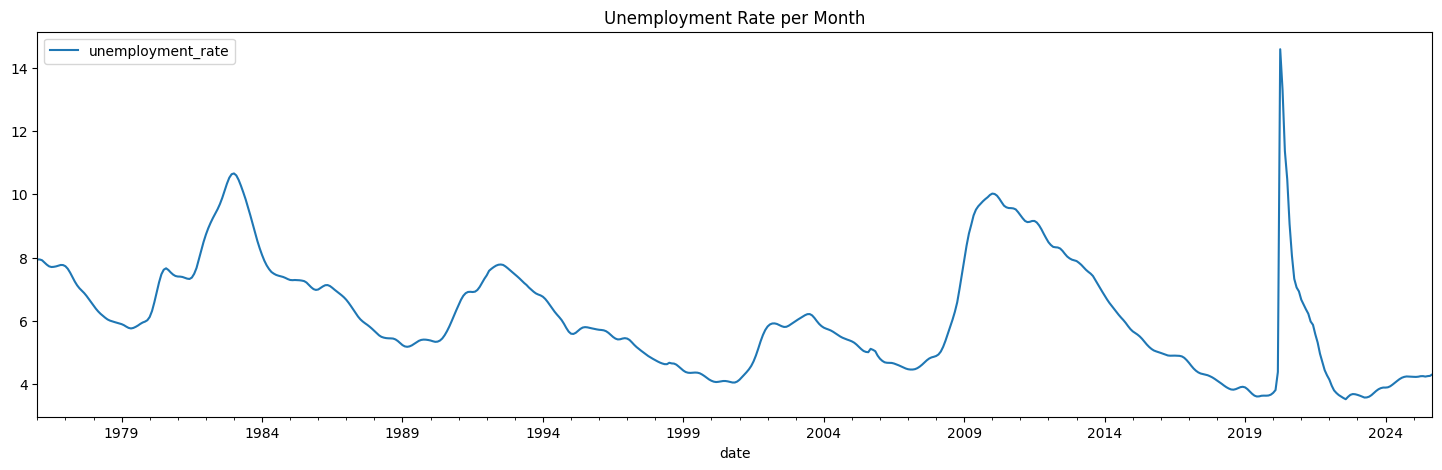

In [217]:
series.plot(figsize=(18, 5))
plt.title('Unemployment Rate per Month')
plt.show()

## Divisão Entre Treino e Teste

In [218]:
train = series[:-1]
test = series[-1:]

print(train.size)
print(test.size)

596
1


## Decomposição STL

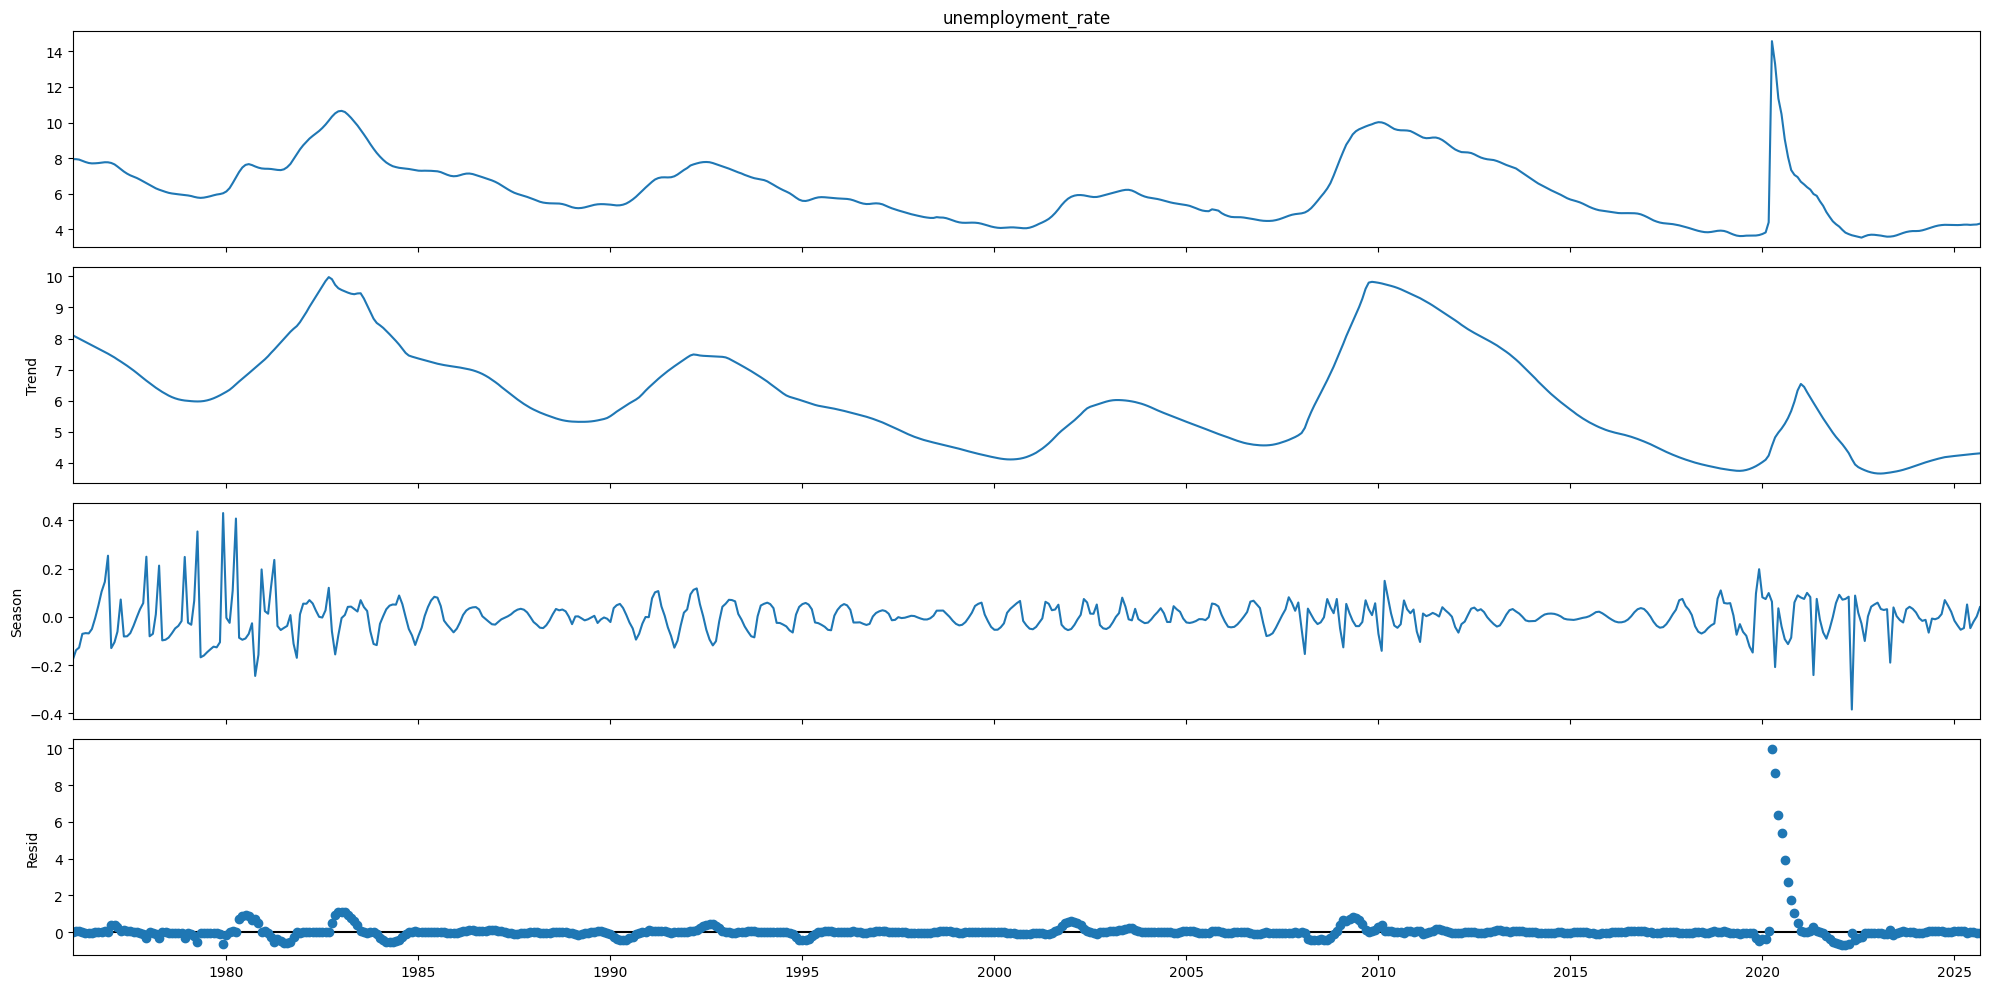

In [219]:
m = 12

stl = STL(
    series['unemployment_rate'],
    period=m,
    robust=True
).fit()

fig = stl.plot()
fig.set_size_inches(20,10)
plt.tight_layout()
plt.show()

## Força da Sazonalidade 

In [220]:
trend = stl.trend
seasonal = stl.seasonal
residual = stl.resid

forca_sazonalidade = max(
    0,
    1 - (
        np.var(residual) /
        np.var(seasonal + residual)
    )
)

forca_tendencia = max(
    0,
    1 - (
        np.var(residual) /
        np.var(trend + residual)
    )
)

# Resultados
print(f'Força da Sazonalidade: {forca_sazonalidade:.4f}')
print(f'Força da Tendência: {forca_tendencia:.4f}')

Força da Sazonalidade: 0.0000
Força da Tendência: 0.8383


## Testes de Estacionariedade

In [221]:
# Funções
def test_adf(x):
    res = adfuller(x)

    results = {
        'ADF Statistic': res[0],
        'p-value': res[1],
        'Critical Values 1/5/10%': res[4],
    }

    print('ADF')

    for k, v in results.items():
        print(f' {k}: {v}')

def test_kpss(x):
    res = kpss(x)

    results = {
        'KPSS Statistic': res[0],
        'p-value': res[1],
        'Critical Values 10/5/2.5/1%': res[3],
    }

    print('KPSS')

    for k, v in results.items():
        print(f' {k}: {v}')

<Figure size 800x400 with 0 Axes>

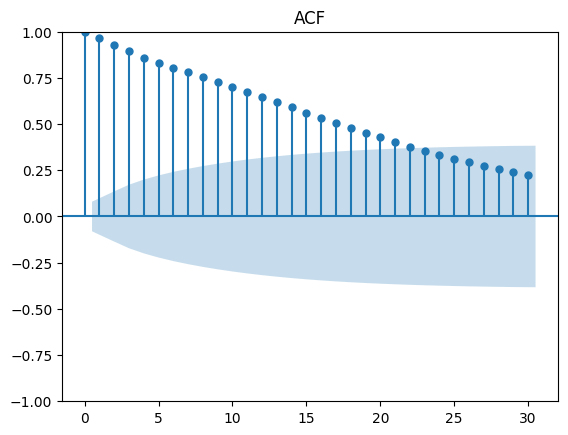

ADF
 ADF Statistic: -3.3312779252402045
 p-value: 0.013536943587341676
 Critical Values 1/5/10%: {'1%': np.float64(-3.441406876071572), '5%': np.float64(-2.866418015869717), '10%': np.float64(-2.5693678601956718)}

KPSS
 KPSS Statistic: 0.6319193522759271
 p-value: 0.019734604338552078
 Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


In [222]:
plt.figure(figsize=(8,4))
plot_acf(train, lags=30)
plt.title('ACF')
plt.show()

test_adf(train)
print()
test_kpss(train)

Para avaliar a estacionariedade da série temporal da taxa de desemprego, foram aplicados os testes estatísticos ADF (*Augmented Dickey-Fuller*) e KPSS (*Kwiatkowski-Phillips-Schmidt-Shin*), além da análise visual da função de autocorrelação (ACF).

A análise do gráfico ACF indica um decaimento lento das autocorrelações ao longo das defasagens, demonstrando forte persistência temporal na série. Esse comportamento é frequentemente associado à presença de tendência e possível não estacionariedade.

### Teste ADF

O teste ADF possui como hipótese nula (\(H_0\)) que a série é não estacionária.

Resultados obtidos:
- Estatística ADF: -3.3313
- p-value: 0.0135

Como o valor-p foi inferior ao nível de significância de 5%, rejeita-se a hipótese nula do teste ADF. Assim, segundo esse teste, há evidências de que a série seja estacionária.

### Teste KPSS

O teste KPSS possui hipótese nula oposta ao ADF, isto é, considera que a série é estacionária.

Resultados obtidos:
- Estatística KPSS: 0.6319
- p-value: 0.0197

Como o valor-p também foi inferior a 5%, rejeita-se a hipótese nula do teste KPSS. Portanto, segundo esse teste, a série apresenta indícios de não estacionariedade.

### Interpretação dos Resultados

Os testes ADF e KPSS apresentaram conclusões conflitantes:
- o teste ADF sugere estacionariedade;
- o teste KPSS sugere não estacionariedade.

Entretanto, a análise visual da ACF demonstra um decaimento gradual e persistente das autocorrelações, comportamento típico de séries com tendência estocástica ou forte persistência temporal. Dessa forma, apesar do resultado do ADF, existem evidências de que a série original não seja completamente estacionária.

Além disso:
- há indícios de tendência na série;
- existe provável necessidade de diferenciação para estabilizar a média da série;
- não foram observadas evidências suficientemente claras de sazonalidade forte que justifiquem, neste momento, a aplicação de diferenciação sazonal.

Portanto, a série provavelmente se beneficiará da aplicação de diferenciação antes da modelagem SARIMA.

## Diferenciação

ADF
 ADF Statistic: -17.91758256700711
 p-value: 2.9141367265537917e-30
 Critical Values 1/5/10%: {'1%': np.float64(-3.4414256033746606), '5%': np.float64(-2.8664262627821473), '10%': np.float64(-2.569372254520843)}

KPSS
 KPSS Statistic: 0.026570517817598987
 p-value: 0.1
 Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


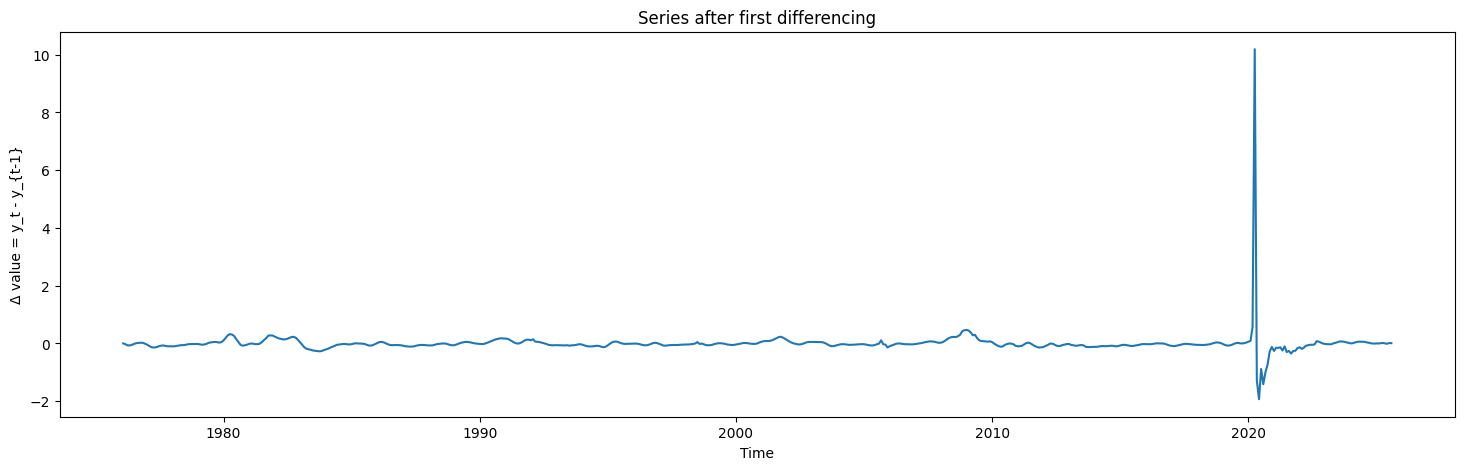

In [223]:
diff = train.diff(1).dropna()

adf_diff = test_adf(diff)
print()
kpss_diff = test_kpss(diff)

plt.figure(figsize=(18,5))
plt.plot(diff.index, diff.values)

plt.title('Series after first differencing')
plt.xlabel('Time')
plt.ylabel('Δ value = y_t - y_{t-1}')

plt.show()

## Análise de ACF e PACF 

<Figure size 800x400 with 0 Axes>

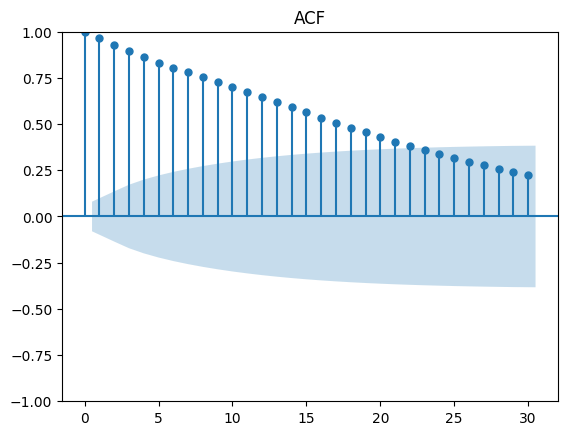

In [224]:
plt.figure(figsize=(8,4))
plot_acf(series, lags=30)
plt.title('ACF')
plt.show()

<Figure size 1000x400 with 0 Axes>

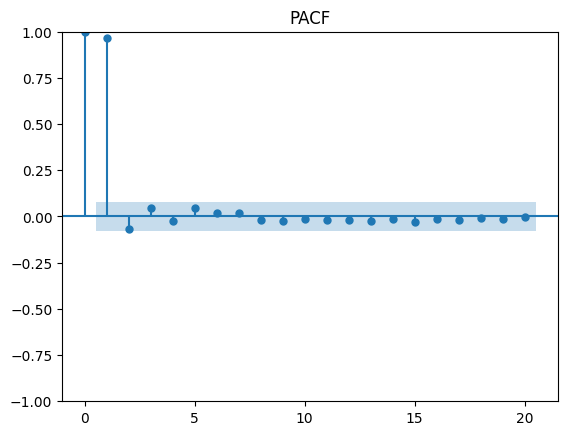

In [225]:
MAX_LAG = 20

plt.figure(figsize=[10,4])
plot_pacf(series, lags=MAX_LAG, title='PACF')
plt.show()

inicialmente, foi realizada a análise visual da série temporal, identificando a presença de tendência e comportamento não estacionário. Para confirmar essa característica, foram aplicados os testes estatísticos ADF (Augmented Dickey-Fuller) e KPSS (Kwiatkowski-Phillips-Schmidt-Shin).
Os resultados obtidos para a série original indicaram não estacionariedade, tornando necessária a aplicação de diferenciação de primeira ordem. Após a diferenciação, a série passou a oscilar em torno de uma média aproximadamente constante, sem tendência aparente.
A estacionariedade da série diferenciada foi confirmada pelos testes estatísticos:

ADF Statistic = −17.9176, p-value = 2.91e−30

Como o valor-p do teste ADF foi significativamente menor que 0,05, rejeitou-se a hipótese nula de não estacionariedade.

KPSS Statistic = 0.0266, p-value = 0.1

No teste KPSS, o valor-p elevado indicou que não foi possível rejeitar a hipótese nula de estacionariedade. Dessa forma, concluiu-se que d = 1.
Em seguida, foram analisados os gráficos ACF e PACF da série diferenciada. Ambos os gráficos apresentaram autocorrelações próximas de zero para praticamente todos os lags, com apenas pequenos picos nos lags iniciais (1 a 4) levemente próximos ao limite da banda de confiança. Não foram observados padrões de decaimento lento, cortes bruscos ou estruturas sazonais evidentes.
Cabe observar que a série apresenta um outlier expressivo em torno de 2020, correspondente a um choque externo de grande magnitude. Esse ponto pode ter contribuído para inflar a variância da série diferenciada, comprimindo visualmente as autocorrelações e dificultando a identificação de padrões mais sutis nos gráficos ACF e PACF.
Com base nessa análise, foram definidos os seguintes parâmetros iniciais para exploração:

p ∈ {0, 1}
d = 1
q ∈ {0, 1}
D = 0, P = 0, Q = 0, m = 0

A ausência de padrões sazonais evidentes nos gráficos justificou a não inclusão de componentes sazonais no modelo.

## Definição dos parâmetros do SARIMA

Após a análise exploratória, foram testadas todas as combinações dos parâmetros
p ∈ {0,1}, d ∈ {0,1}, q ∈ {0,1}, mantendo os componentes sazonais nulos
(P = D = Q = 0, m = 0). Os modelos foram ajustados diretamente sobre a série
original, permitindo que o parâmetro d fosse avaliado internamente pelo SARIMAX.
A comparação foi realizada pelo critério BIC.

O ranking obtido foi:

| Modelo                      | BIC    |
|-----------------------------|--------|
| SARIMA(0,1,0)(0,0,0,0)      | 742.32 |
| SARIMA(0,1,1)(0,0,0,0)      | 746.51 |
| SARIMA(1,1,0)(0,0,0,0)      | 747.02 |
| SARIMA(1,0,0)(0,0,0,0)      | 747.57 |
| SARIMA(1,1,1)(0,0,0,0)      | 750.31 |

Os modelos com d=0 apresentaram BIC muito superior (acima de 3.000), confirmando
que a diferenciação é indispensável. Entre os modelos com d=1, a diferença de BIC
entre o melhor e o quinto colocado foi de aproximadamente 8 pontos, indicando que
os modelos mais complexos não trouxeram ganho expressivo de ajuste.

Com base no princípio da parcimônia e no critério BIC, foi selecionado o modelo
**SARIMA(0,1,0)(0,0,0,0)**, equivalente a um processo de passeio aleatório
(*random walk*). Esse resultado é consistente com os gráficos ACF e PACF, que
indicaram ausência de autocorrelações significativas após a diferenciação,
sugerindo que o incremento da série se comporta próximo de ruído branco.

## Construção dos Base Models

In [226]:
# Código aqui

## Treinamento do Modelo SARIMA

In [227]:
h = 6

p_range = [0, 1]
d_range = [0, 1]
q_range = [0, 1]

P_range = [0]
D_range = [0]
Q_range = [0]

m = 0

orders = list(itertools.product(p_range, d_range, q_range))
seasonal_orders = list(itertools.product(P_range, D_range, Q_range))

def fit_sarima(order, seasonal_order, series):

    model = SARIMAX(
        series,
        order=order,
        seasonal_order=(*seasonal_order, m),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    return {
        'model': f'SARIMA{order}{(*seasonal_order, m)}',
        'bic': result.bic
    }

results = []

for order in orders:
    for seasonal_order in seasonal_orders:

        result = fit_sarima(
            order,
            seasonal_order,
            train
        )

        results.append(result)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='bic')

print(results_df)

                         model          bic
2  SARIMA(0, 1, 0)(0, 0, 0, 0)   742.323649
3  SARIMA(0, 1, 1)(0, 0, 0, 0)   746.511036
6  SARIMA(1, 1, 0)(0, 0, 0, 0)   747.021139
4  SARIMA(1, 0, 0)(0, 0, 0, 0)   747.570136
7  SARIMA(1, 1, 1)(0, 0, 0, 0)   750.314772
5  SARIMA(1, 0, 1)(0, 0, 0, 0)   751.681789
1  SARIMA(0, 0, 1)(0, 0, 0, 0)  3133.120804
0  SARIMA(0, 0, 0)(0, 0, 0, 0)  3903.908024


## Diagnóstico dos resíduos

In [228]:
# Código aqui

## Avaliação de desempenho 

In [229]:
# Código aqui

## Rolling Forecast

In [230]:
# Código aqui